## **Alumno: Carlos ALberto Vidrios Serrano**
# TAE-IA · Module 6 · L16 — Audio Classification: The Spectrogram Trick

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L16 |
| **Track** | B — Audio |
| **Runtime** | CPU sufficient for preprocessing (~15 min); GPU not required |
| **Drive output** | `ESC-50/` (~600 MB) + `ESC50_specs/` (~30 MB) |

## Learning objectives

By the end of this notebook you will be able to:
1. Download and explore the ESC-50 dataset (2000 clips, 50 categories, 5-fold CV structure)
2. Implement a complete `audio → mel spectrogram → 128×128 PNG` preprocessing pipeline
3. Verify that spectrograms from different categories are visually distinguishable
4. Implement SpecAugment (time masking + frequency masking) and understand its role
5. Build a `torch.utils.data.Dataset` that loads PNG spectrograms ready for L17 training

---

## Drive space check

Before running this notebook, verify you have **≥15 GB free** on Google Drive:
- ESC-50 raw audio: ~600 MB
- Preprocessed PNGs: ~30 MB
- Remaining BLIP-2 + CLIP already on Drive: ~5.6 GB

---

## Cell 0 — Setup

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, subprocess
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

# Dataset paths
ESC50_DIR = '/content/drive/MyDrive/TAE_IA_M6/ESC-50'
SPEC_DIR  = '/content/drive/MyDrive/TAE_IA_M6/ESC50_specs'

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU available: {torch.cuda.get_device_name(0)} (not needed for L16)')
else:
    print('CPU runtime — correct for L16 preprocessing')

print(f'\nESC50_DIR = {ESC50_DIR}')
print(f'SPEC_DIR  = {SPEC_DIR}')

Mounted at /content/drive
PyTorch: 2.11.0+cu128
GPU available: Tesla T4 (not needed for L16)

ESC50_DIR = /content/drive/MyDrive/TAE_IA_M6/ESC-50
SPEC_DIR  = /content/drive/MyDrive/TAE_IA_M6/ESC50_specs


In [2]:
!pip install librosa soundfile pillow tqdm -q

import librosa
import librosa.display
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as ipd
from PIL import Image
from tqdm.auto import tqdm

print(f'librosa {librosa.__version__}')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

librosa 0.11.0


---
## Section 2.1 — Download ESC-50

ESC-50 is hosted on GitHub. The download is ~600 MB and clones directly to Drive so it persists across sessions.

**If the clone fails** (network timeout on Colab), re-run this cell — `git clone` is idempotent with the `--no-checkout` check we add.

In [3]:
if os.path.exists(os.path.join(ESC50_DIR, 'meta', 'esc50.csv')):
    print('ESC-50 already on Drive — skipping download.')
else:
    print('Downloading ESC-50 to Drive (~600 MB, ~2–3 min)...')
    os.makedirs(ESC50_DIR, exist_ok=True)
    result = subprocess.run(
        ['git', 'clone', '--depth=1',
         'https://github.com/karoldvl/ESC-50.git',
         ESC50_DIR],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print('git clone failed:', result.stderr)
        print('Try re-running this cell.')
    else:
        print('Download complete.')

# Verify
audio_dir = os.path.join(ESC50_DIR, 'audio')
n_wavs = len([f for f in os.listdir(audio_dir) if f.endswith('.wav')])
print(f'WAV files found: {n_wavs}  (expected: 2000)')

ESC-50 already on Drive — skipping download.
WAV files found: 2000  (expected: 2000)


---
## Section 2.2 — Explore Metadata

In [4]:
meta = pd.read_csv(os.path.join(ESC50_DIR, 'meta', 'esc50.csv'))

print('=== Dataset overview ===')
print(f'Total clips:    {len(meta)}')
print(f'Categories:     {meta["category"].nunique()}')
print(f'Folds:          {sorted(meta["fold"].unique())}')
print(f'Clips per fold: {meta["fold"].value_counts().sort_index().to_dict()}')
print()
print('Columns:', list(meta.columns))
print()
meta.head(10)

=== Dataset overview ===
Total clips:    2000
Categories:     50
Folds:          [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Clips per fold: {1: 400, 2: 400, 3: 400, 4: 400, 5: 400}

Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']



,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A
5,1-101296-B-19.wav,1,19,thunderstorm,False,101296,B
6,1-101336-A-30.wav,1,30,door_wood_knock,False,101336,A
7,1-101404-A-34.wav,1,34,can_opening,False,101404,A
8,1-103298-A-9.wav,1,9,crow,False,103298,A
9,1-103995-A-30.wav,1,30,door_wood_knock,False,103995,A


All categories have exactly 40 clips: True
Target IDs range: 0 – 49


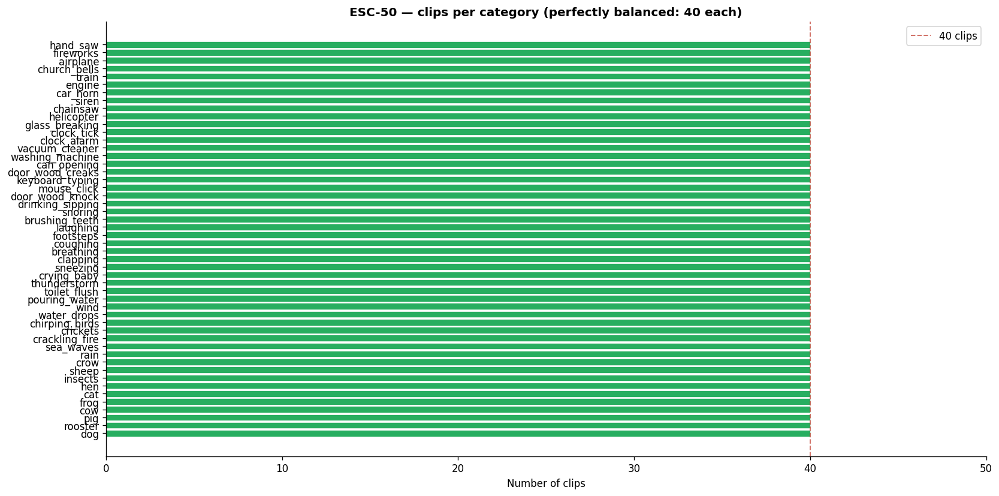

In [5]:
# Category distribution — should be perfectly balanced (40 clips each)
counts = meta.groupby(['target', 'category']).size().reset_index(name='count')
counts = counts.sort_values('target')

print(f'All categories have exactly 40 clips: {(counts["count"] == 40).all()}')
print(f'Target IDs range: {counts["target"].min()} – {counts["target"].max()}')

# Plot all 50 categories
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(counts['category'], counts['count'],
               color='#27ae60', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Number of clips')
ax.set_title('ESC-50 — clips per category (perfectly balanced: 40 each)',
             fontweight='bold')
ax.axvline(40, color='#c0392b', linewidth=1.2, linestyle='--', alpha=0.7, label='40 clips')
ax.set_xlim(0, 50)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# 5-fold cross-validation structure
# Standard protocol: train on folds 1-4, test on fold 5; rotate
# In L17 we will use fold 5 as test, folds 1-4 as training

train_meta = meta[meta['fold'] != 5]
test_meta  = meta[meta['fold'] == 5]

print('Train/test split (fold 5 held out):')
print(f'  Train: {len(train_meta)} clips (folds 1–4)')
print(f'  Test:  {len(test_meta)} clips (fold 5)')
print(f'  Ratio: {len(train_meta)/len(meta)*100:.0f}% / {len(test_meta)/len(meta)*100:.0f}%')
print()
print('Clips per category in test set:')
print(test_meta['category'].value_counts().describe())
print('→ 8 clips per category in test fold (exactly 40/5)')

Train/test split (fold 5 held out):
  Train: 1600 clips (folds 1–4)
  Test:  400 clips (fold 5)
  Ratio: 80% / 20%

Clips per category in test set:
count    50.0
mean      8.0
std       0.0
min       8.0
25%       8.0
50%       8.0
75%       8.0
max       8.0
Name: count, dtype: float64
→ 8 clips per category in test fold (exactly 40/5)


---
## Section 2.3 — Listen to Examples

Before building spectrograms, listen to 5 representative clips to understand the audio content.

In [7]:
listen_categories = ['dog', 'rain', 'coughing', 'chainsaw', 'crickets']

for cat in listen_categories:
    row = meta[meta['category'] == cat].iloc[0]
    wav_path = os.path.join(ESC50_DIR, 'audio', row['filename'])
    y, sr = librosa.load(wav_path, sr=22050, mono=True)
    print(f'\n▶ {cat.upper()}  ({row["filename"]}, {len(y)/sr:.1f}s)')
    ipd.display(ipd.Audio(y, rate=sr))


▶ DOG  (1-100032-A-0.wav, 5.0s)



▶ RAIN  (1-17367-A-10.wav, 5.0s)



▶ COUGHING  (1-19111-A-24.wav, 5.0s)



▶ CHAINSAW  (1-116765-A-41.wav, 5.0s)



▶ CRICKETS  (1-57316-A-13.wav, 5.0s)


---
## Section 2.4 — Preprocessing Pipeline

The `audio_to_mel_png` function is the core of this lesson. Every design decision here affects what the CNN in L17 can learn.

**Pipeline decisions:**
- `sr=22050` — enough for music/ambient (max 11025 Hz); use 16000 only for speech-only tasks
- `duration=5` — all ESC-50 clips are nominally 5 s
- `n_mels=128`, `fmax=8000` — standard for audio classification
- `n_fft=2048`, `hop_length=512` — balanced time/freq resolution
- Per-clip dB normalisation — each clip's dynamic range → [0, 255]
- `np.flipud` — low frequency at bottom (matching human spectrogram convention)

Test clip: 1-100032-A-0.wav  category=dog
Output PNG: size=(128, 128), mode=L


/tmp/ipykernel_442/1120671898.py:32: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(S_norm, mode='L')  # grayscale


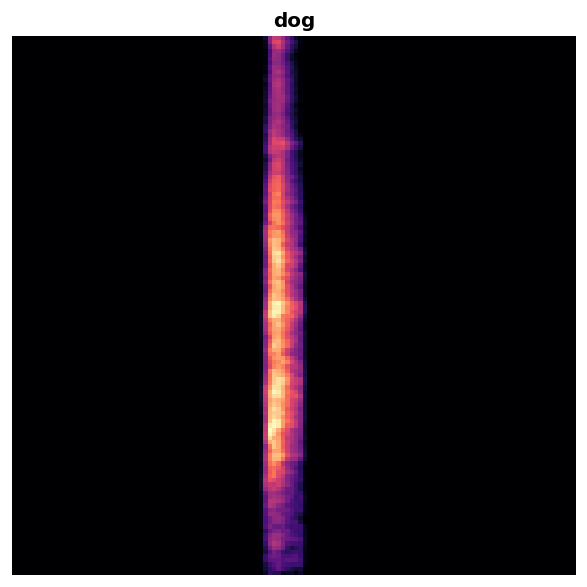

In [8]:
TARGET_SR      = 22050
TARGET_SAMPLES = TARGET_SR * 5   # 110,250 samples
N_FFT          = 2048
HOP_LENGTH     = 512
N_MELS         = 128
FMAX           = 8000
IMG_SIZE       = 128

def audio_to_mel_png(wav_path, out_path):
    """Load WAV, trim/pad to 5s, compute mel spectrogram, save as 128×128 PNG."""
    y, _ = librosa.load(wav_path, sr=TARGET_SR, mono=True)

    # Fixed-length
    if len(y) > TARGET_SAMPLES:
        y = y[:TARGET_SAMPLES]
    elif len(y) < TARGET_SAMPLES:
        y = np.pad(y, (0, TARGET_SAMPLES - len(y)))

    # Mel spectrogram
    S     = librosa.feature.melspectrogram(
                y=y, sr=TARGET_SR,
                n_fft=N_FFT, hop_length=HOP_LENGTH,
                n_mels=N_MELS, fmax=FMAX
            )
    S_db  = librosa.power_to_db(S, ref=np.max)

    # Normalise to uint8
    S_min, S_max = S_db.min(), S_db.max()
    S_norm = ((S_db - S_min) / (S_max - S_min + 1e-8) * 255).astype(np.uint8)
    S_norm = np.flipud(S_norm)   # low freq at bottom

    img = Image.fromarray(S_norm, mode='L')  # grayscale
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    img.save(out_path)

# Quick test on one clip
test_row = meta.iloc[0]
test_wav = os.path.join(ESC50_DIR, 'audio', test_row['filename'])
test_png = '/tmp/test_spec.png'
audio_to_mel_png(test_wav, test_png)

img = Image.open(test_png)
print(f'Test clip: {test_row["filename"]}  category={test_row["category"]}')
print(f'Output PNG: size={img.size}, mode={img.mode}')

# audio_to_mel_png() already flipped on write, so the default origin is correct
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.array(img), cmap='magma', aspect='auto')
ax.set_title(f'{test_row["category"]}', fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Section 2.5 — Run the Full Pipeline (all 2000 clips)

This cell processes all 2000 WAV files. It takes approximately **10–15 minutes on Colab CPU**.

The cell is idempotent — re-running it skips already-processed files.

In [9]:
os.makedirs(SPEC_DIR, exist_ok=True)

errors = []
skipped = 0
processed = 0

for _, row in tqdm(meta.iterrows(), total=len(meta), desc='Preprocessing ESC-50'):
    wav_path = os.path.join(ESC50_DIR, 'audio', row['filename'])
    png_name = row['filename'].replace('.wav', '.png')
    out_path = os.path.join(SPEC_DIR, png_name)

    if os.path.exists(out_path):
        skipped += 1
        continue

    try:
        audio_to_mel_png(wav_path, out_path)
        processed += 1
    except Exception as e:
        errors.append((row['filename'], str(e)))

print(f'\nProcessed: {processed}  |  Skipped (already exist): {skipped}  |  Errors: {len(errors)}')
if errors:
    print('Errors:')
    for fname, err in errors:
        print(f'  {fname}: {err}')

# Verify count
n_pngs = len([f for f in os.listdir(SPEC_DIR) if f.endswith('.png')])
print(f'\nPNGs on Drive: {n_pngs} / 2000')

Preprocessing ESC-50:   0%|          | 0/2000 [00:00<?, ?it/s]


Processed: 0  |  Skipped (already exist): 2000  |  Errors: 0

PNGs on Drive: 2000 / 2000


---
## Section 2.6 — Category Visualisation

Visualise 5 spectrogram examples from 10 different categories. The key question: can you tell them apart visually? If yes, a CNN can too.

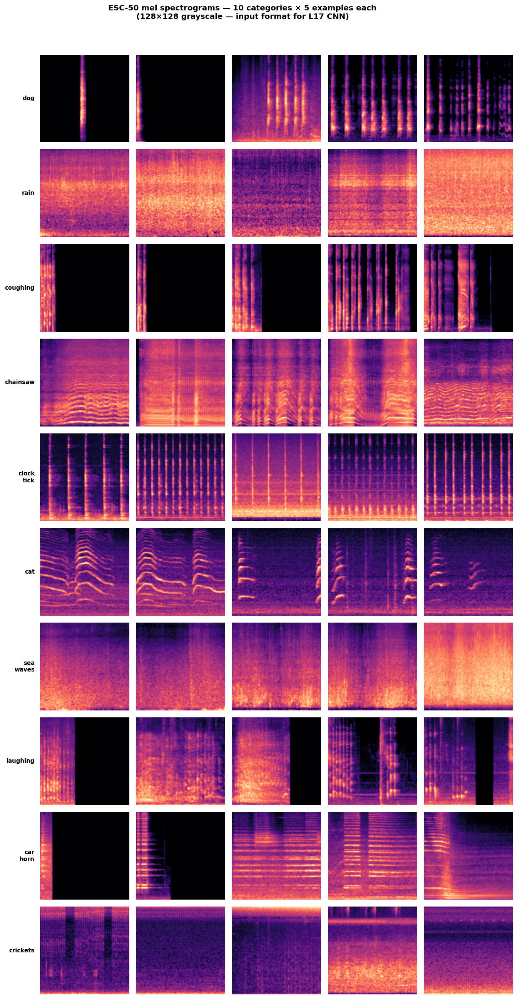

In [10]:
categories_to_show = [
    'dog', 'rain', 'coughing', 'chainsaw', 'clock_tick',
    'cat', 'sea_waves', 'laughing', 'car_horn', 'crickets'
]

fig, axes = plt.subplots(len(categories_to_show), 5,
                          figsize=(12, 2.2 * len(categories_to_show)))

for row_idx, cat in enumerate(categories_to_show):
    clips = meta[meta['category'] == cat].head(5)
    for col_idx, (_, clip_row) in enumerate(clips.iterrows()):
        png_path = os.path.join(SPEC_DIR, clip_row['filename'].replace('.wav', '.png'))
        ax = axes[row_idx, col_idx]
        if os.path.exists(png_path):
            ax.imshow(np.array(Image.open(png_path)), cmap='magma',
                      aspect='auto')
        else:
            ax.text(0.5, 0.5, 'missing', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        if col_idx == 0:
            # axis('off') suppresses set_ylabel, so draw the row label directly
            ax.text(-0.06, 0.5, cat.replace('_', '\n'), transform=ax.transAxes,
                    fontsize=9, fontweight='bold', ha='right', va='center')

plt.suptitle('ESC-50 mel spectrograms — 10 categories × 5 examples each\n'
             '(128×128 grayscale — input format for L17 CNN)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0.06, 0, 1, 0.96])
plt.show()

---
## Section 2.7 — SpecAugment

SpecAugment is applied **during training** (not saved to disk). Here we visualise its effect so you understand what the model sees during L17 training.

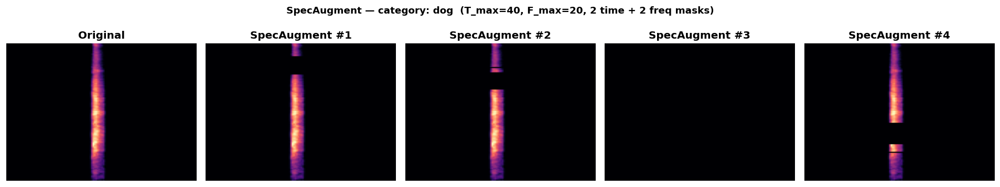

In [11]:
import torch

def time_mask(spec, T_max=40):
    """Zero out T consecutive time frames. spec shape: (F, T)"""
    t  = random.randint(0, T_max)
    t0 = random.randint(0, max(0, spec.shape[1] - t))
    out = spec.clone()
    out[:, t0:t0+t] = 0.0
    return out

def freq_mask(spec, F_max=20):
    """Zero out F consecutive mel bands. spec shape: (F, T)"""
    f  = random.randint(0, F_max)
    f0 = random.randint(0, max(0, spec.shape[0] - f))
    out = spec.clone()
    out[f0:f0+f, :] = 0.0
    return out

def spec_augment(spec, T_max=40, F_max=20, num_T=2, num_F=2):
    """Apply SpecAugment: num_T time masks + num_F frequency masks."""
    out = spec.clone()
    for _ in range(num_T):
        out = time_mask(out, T_max)
    for _ in range(num_F):
        out = freq_mask(out, F_max)
    return out

# Load a reference spectrogram as a tensor
ref_row = meta[meta['category'] == 'dog'].iloc[0]
ref_png = os.path.join(SPEC_DIR, ref_row['filename'].replace('.wav', '.png'))
ref_arr = np.array(Image.open(ref_png)).astype(np.float32) / 255.0
ref_t   = torch.from_numpy(ref_arr)  # shape: (128, 128)

# Generate 4 augmented variants
random.seed(7)
torch.manual_seed(7)
augmented = [spec_augment(ref_t, T_max=40, F_max=20, num_T=2, num_F=2)
             for _ in range(4)]

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
axes[0].imshow(ref_arr, cmap='magma', aspect='auto')
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i, aug in enumerate(augmented):
    axes[i+1].imshow(aug.numpy(), cmap='magma', aspect='auto')
    axes[i+1].set_title(f'SpecAugment #{i+1}', fontweight='bold')
    axes[i+1].axis('off')

plt.suptitle(f'SpecAugment — category: {ref_row["category"]}  '
             f'(T_max=40, F_max=20, 2 time + 2 freq masks)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.8 — PyTorch Dataset (ready for L17)

Define the `ESC50Dataset` class that L17 will import. It loads PNG files, converts them to tensors, and optionally applies SpecAugment.

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class ESC50Dataset(Dataset):
    """
    Loads preprocessed 128×128 mel spectrogram PNGs for ESC-50.

    Args:
        meta_df   : filtered DataFrame rows (e.g., fold != 5 for training)
        spec_dir  : directory containing the PNG files
        augment   : if True, apply SpecAugment (use only during training)
        img_size  : resize to this square size (default 128, EfficientNet uses 224)
    """
    def __init__(self, meta_df, spec_dir, augment=False, img_size=128):
        self.meta     = meta_df.reset_index(drop=True)
        self.spec_dir = spec_dir
        self.augment  = augment
        self.base_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),          # (H, W) uint8 → (1, H, W) float32 in [0, 1]
            T.Lambda(lambda x: x.repeat(3, 1, 1)),  # 1-channel → 3-channel (RGB expected by EfficientNet)
            T.Normalize(mean=[0.5, 0.5, 0.5],
                        std=[0.5, 0.5, 0.5]),        # → [-1, 1]
        ])

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row      = self.meta.iloc[idx]
        png_name = row['filename'].replace('.wav', '.png')
        img      = Image.open(os.path.join(self.spec_dir, png_name)).convert('L')
        tensor   = self.base_transform(img)    # (3, img_size, img_size)

        if self.augment:
            # SpecAugment applied on the single channel before 3× repeat
            single = tensor[0]  # (H, W) is already (F, T) — what the masks expect
            single = time_mask(single, T_max=30)
            single = freq_mask(single, F_max=15)
            tensor = single.unsqueeze(0).repeat(3, 1, 1)

        label = int(row['target'])
        return tensor, label

# Verify the dataset
train_ds = ESC50Dataset(train_meta, SPEC_DIR, augment=False)
test_ds  = ESC50Dataset(test_meta,  SPEC_DIR, augment=False)

print(f'Train dataset: {len(train_ds)} samples')
print(f'Test  dataset: {len(test_ds)} samples')

# Check a batch
loader = DataLoader(train_ds, batch_size=8, shuffle=True)
imgs, labels = next(iter(loader))
print(f'Batch shape:   {imgs.shape}  dtype={imgs.dtype}  '
      f'range=[{imgs.min():.2f}, {imgs.max():.2f}]')
print(f'Labels:        {labels.tolist()}')

Train dataset: 1600 samples
Test  dataset: 400 samples
Batch shape:   torch.Size([8, 3, 128, 128])  dtype=torch.float32  range=[-1.00, 0.99]
Labels:        [12, 28, 24, 10, 48, 3, 9, 15]


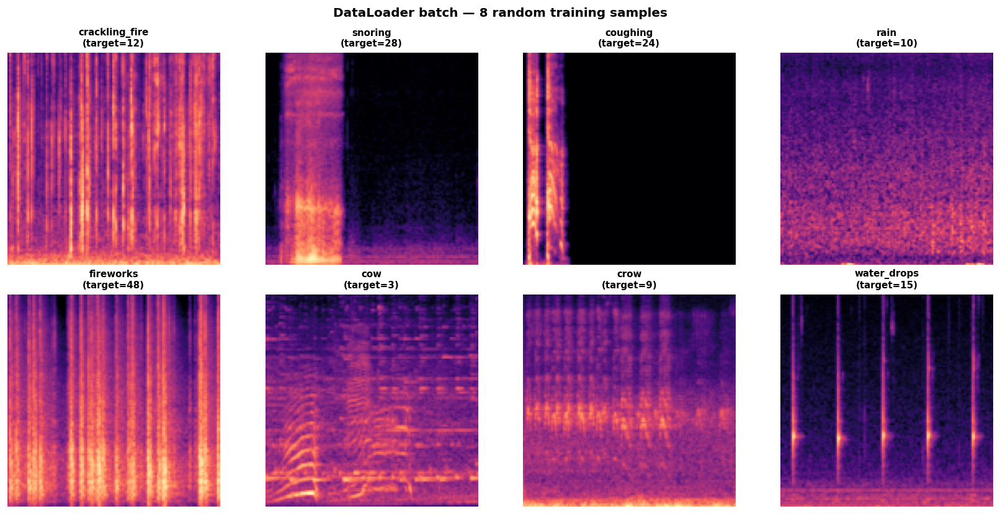

In [13]:
# Visualise a batch from the DataLoader
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img_t, label in zip(axes.flat, imgs, labels):
    # Un-normalise for display: [-1,1] → [0,1]
    img_disp = (img_t[0].numpy() * 0.5 + 0.5)
    cat_name = meta[meta['target'] == label.item()]['category'].iloc[0]
    ax.imshow(img_disp, cmap='magma', vmin=0, vmax=1)
    ax.set_title(f'{cat_name}\n(target={label.item()})', fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('DataLoader batch — 8 random training samples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Exercise 1 — Visually difficult pairs

From the Section 2.6 visualisation, identify **two category pairs** whose spectrograms look most similar to each other.

1. Name the two pairs
2. For each pair, describe what acoustic property makes them look similar in the spectrogram
3. Listen to one clip from each category in each pair (use `ipd.Audio`). Does the perceptual similarity match the visual similarity?

This exercise builds intuition for where L17's classifier will struggle — the hardest category pairs will appear as off-diagonal confusion matrix entries.

  rain:


  sea_waves:


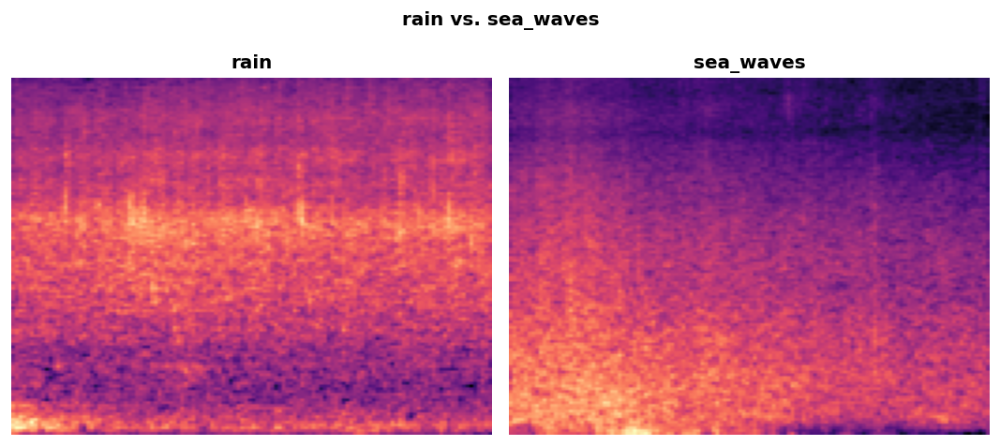

  dog:


  cat:


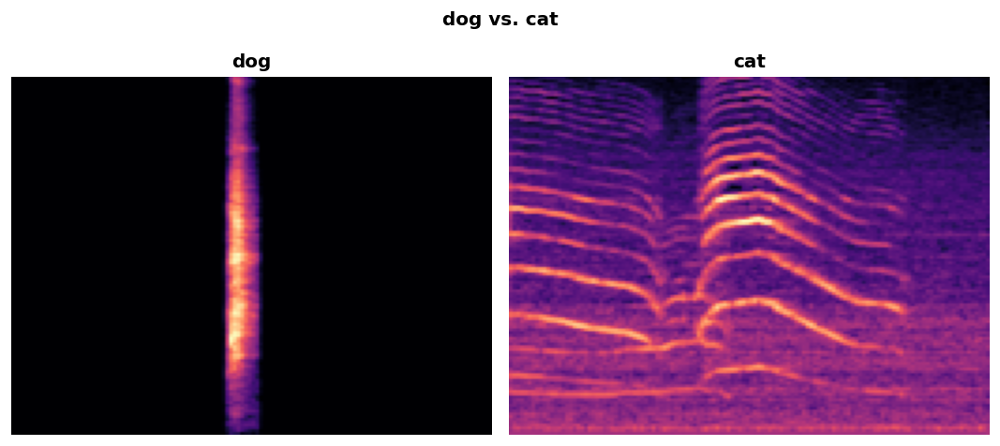

In [14]:
# Exercise 1 -- Visually difficult pairs

def compare_categories(cat_a, cat_b):
    for cat in [cat_a, cat_b]:
        row = meta[meta['category'] == cat].iloc[0]
        y, sr = librosa.load(
            os.path.join(ESC50_DIR, 'audio', row['filename']),
            sr=TARGET_SR,
            mono=True
        )

        print(f'  {cat}:')
        ipd.display(ipd.Audio(y, rate=sr))

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    for ax, cat in zip(axes, [cat_a, cat_b]):
        row = meta[meta['category'] == cat].iloc[0]
        png = os.path.join(
            SPEC_DIR,
            row['filename'].replace('.wav', '.png')
        )

        ax.imshow(
            np.array(Image.open(png)),
            cmap='magma',
            aspect='auto'
        )
        ax.set_title(cat, fontweight='bold')
        ax.axis('off')

    plt.suptitle(
        f'{cat_a} vs. {cat_b}',
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# Pair 1: sonidos naturales con energía distribuida
pair_1 = ('rain', 'sea_waves')

# Pair 2: sonidos de animales con patrones temporales similares
pair_2 = ('dog', 'cat')


# Visual comparison
compare_categories(*pair_1)
compare_categories(*pair_2)

**Exercise 1 — Answer:**

[YOUR ANSWER — name the two pairs, describe the acoustic similarity, and whether listening confirms the visual similarity]

**Parte 1: `rain` y `sea_waves`**

Estas dos categorías presentan espectrogramas visualmente similares debido a que ambas contienen una distribución de energía relativamente continua a lo largo del tiempo y una importante cantidad de energía distribuida en diferentes bandas de frecuencia. En lugar de presentar eventos acústicos aislados, ambas señales producen patrones más continuos y difusos en el espectrograma.

Al escuchar un clip de cada categoría, la similitud visual se corresponde parcialmente con la similitud perceptual, ya que tanto la lluvia como las olas del mar producen sonidos ambientales continuos. Sin embargo, auditivamente es posible distinguirlas por sus diferentes características temporales: la lluvia presenta numerosos eventos pequeños y repetitivos, mientras que las olas presentan variaciones más lentas y pronunciadas en intensidad.

**Parte 2: `dog` y `cat`**

Los espectrogramas de `dog` y `cat` pueden presentar similitud debido a que ambos corresponden a vocalizaciones animales con patrones acústicos no estacionarios, caracterizados por cambios rápidos de energía y contenido frecuencial a lo largo del tiempo. Estas características producen estructuras localizadas y variables en el espectrograma.

Al escuchar los clips, la similitud perceptual también se presenta parcialmente, ya que ambas categorías corresponden a sonidos de animales y pueden compartir determinadas características acústicas. No obstante, el oído humano puede distinguir diferencias en el tono, la duración y la estructura de las vocalizaciones que no necesariamente son evidentes únicamente mediante la representación visual.


---
## Exercise 2 — SpecAugment parameter sensitivity

Run `spec_augment` with three different parameter settings on the same clip:
- Setting A: `T_max=10, F_max=5, num_T=1, num_F=1` (mild)
- Setting B: `T_max=40, F_max=20, num_T=2, num_F=2` (standard)
- Setting C: `T_max=80, F_max=40, num_T=4, num_F=4` (aggressive)

Plot all four (original + 3 settings) side-by-side. Then in a markdown cell: at what point does SpecAugment become counterproductive? What signal would you look for during training to detect over-augmentation?



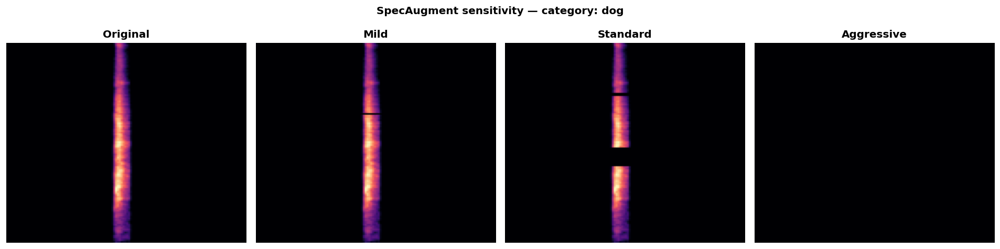

In [15]:
# Exercise 2 -- SpecAugment parameter sensitivity

settings = [
    ('Mild',       dict(T_max=10, F_max=5,  num_T=1, num_F=1)),
    ('Standard',   dict(T_max=40, F_max=20, num_T=2, num_F=2)),
    ('Aggressive', dict(T_max=80, F_max=40, num_T=4, num_F=4)),
]

# Reproducible augmentation
random.seed(99)
torch.manual_seed(99)

# Create 1x4 figure
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original spectrogram
axes[0].imshow(
    ref_arr,
    cmap='magma',
    aspect='auto'
)
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

# Apply each SpecAugment configuration
for ax, (name, kwargs) in zip(axes[1:], settings):

    augmented = spec_augment(
        ref_t,
        **kwargs
    )

    ax.imshow(
        augmented.numpy(),
        cmap='magma',
        aspect='auto'
    )

    ax.set_title(name, fontweight='bold')
    ax.axis('off')

plt.suptitle(
    f'SpecAugment sensitivity — category: {ref_row["category"]}',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**Exercise 2 — Answer:**

[YOUR ANSWER — at what point does SpecAugment become counterproductive? What training signal indicates over-augmentation?]


Al comparar las tres configuraciones de SpecAugment, la configuración **A (Mild)** produce modificaciones pequeñas sobre el espectrograma original, por lo que conserva la mayor parte de la información acústica. La configuración **B (Standard)** introduce modificaciones más importantes mediante el enmascaramiento de regiones temporales y frecuenciales, pero todavía conserva suficientes características relevantes de la señal. La configuración **C (Aggressive)** puede llegar a eliminar una cantidad excesiva de información temporal y frecuencial, dificultando que el modelo identifique las características necesarias para clasificar correctamente el audio.

SpecAugment comienza a ser **contraproducente cuando la intensidad del enmascaramiento elimina una proporción demasiado grande de las características discriminativas de la señal**. En este caso, la aumentación deja de funcionar como una forma de generar variaciones útiles y comienza a generar ejemplos excesivamente distorsionados.

Una señal durante el entrenamiento que permite detectar una sobre-aumentación es que **la precisión de validación comienza a disminuir o la pérdida de validación deja de mejorar**, mientras que el desempeño sobre el conjunto de entrenamiento puede continuar mejorando. Esto indica que las transformaciones aplicadas están dificultando demasiado el aprendizaje de las características relevantes.

---
## Part 4 — Critical Analysis

### Q1 — The image-audio bridge assumption

Treating a mel spectrogram as an image assumes that CNN features learned on natural images (edges, textures, Gabor filters) transfer to audio spectrograms. Name **one CNN feature type** that clearly does transfer and explain why, and **one feature type** that clearly does not transfer and explain what would need to be learned from scratch.

**[YOUR ANSWER]** *(~4 sentences)*

####Una característica de las CNN que sí se transfiere claramente a los espectrogramas es la detección de bordes, ya que los cambios abruptos de energía entre diferentes regiones de tiempo y frecuencia producen estructuras similares a los bordes presentes en imágenes. Los filtros locales también pueden detectar patrones repetitivos o texturas en un espectrograma, independientemente de que representen una imagen o una señal de audio. En cambio, características específicas de imágenes naturales, como patrones de color o partes semánticas de objetos, no tienen una correspondencia directa en un espectrograma de audio en escala de grises. Estas características tendrían que aprenderse desde cero en términos de patrones acústicos, como estructuras temporales, componentes frecuenciales, armónicos y transitorios.
---

### Q2 — Per-clip normalisation and the silent clip problem

Our `audio_to_mel_png` function applies per-clip normalisation: each clip's dB range is stretched to [0, 255]. Consider a clip that is nearly silent — the microphone recorded almost nothing.

1. What will the per-clip normalised spectrogram look like for such a clip?
2. How would this fool a classifier trained on these normalised images?
3. Propose a simple change to `audio_to_mel_png` that would handle this case correctly.

**[YOUR ANSWER]** *(~4 sentences)*

####En un clip casi silencioso, la normalización independiente por clip puede ampliar las pequeñas diferencias presentes en el ruido de fondo hasta ocupar prácticamente todo el rango de valores de 0 a 255, haciendo que el espectrograma parezca contener estructuras de energía importantes. Esto podría confundir al clasificador, ya que el modelo podría interpretar las variaciones del ruido como características relevantes de alguna de las categorías. Una solución sencilla sería detectar previamente los clips con energía muy baja mediante, por ejemplo, su valor RMS y evitar aplicarles la normalización min-max convencional. Otra alternativa sería utilizar un rango fijo de decibeles para todos los clips, en lugar de escalar individualmente el mínimo y máximo de cada espectrograma.
---

### Q3 — Fold leakage

ESC-50's fold structure ensures that clips from the same source recording are always in the same fold. Why is this important? What would happen to the reported test accuracy if clips from the same recording appeared in both the train and test folds? Would the model be better or worse in real-world deployment?

**[YOUR ANSWER]** *(~3 sentences)*

####La separación por folds es importante porque garantiza que los fragmentos provenientes de una misma grabación original permanezcan dentro del mismo fold, evitando que información prácticamente idéntica aparezca tanto en entrenamiento como en prueba. Si fragmentos de una misma grabación estuvieran presentes en ambos conjuntos, el modelo podría aprender características específicas de esa grabación en lugar de aprender características generales de la categoría, provocando una sobreestimación de la precisión de prueba. Por lo tanto, aunque la precisión aparente sería mayor, el desempeño real durante el despliegue sobre nuevas grabaciones podría ser considerablemente menor.
---

### Q4 — Baseline interpretation

From the baseline table: human accuracy on ESC-50 is ~81%. A student trains an EfficientNet model and achieves 75% accuracy. They conclude: "my model is worse than a human." Is this a fair conclusion? What additional comparisons would you need to make before drawing a meaningful conclusion?

**[YOUR ANSWER]** *(~3 sentences)*

####No es suficiente concluir que el modelo es peor que un ser humano únicamente porque obtuvo una precisión de 75 % frente a un baseline humano de aproximadamente 81 %. Para realizar una comparación válida sería necesario comprobar que ambos resultados se obtuvieron sobre los mismos ejemplos de prueba, utilizando las mismas categorías y un protocolo de evaluación comparable. También sería conveniente considerar la variabilidad de la evaluación humana, comparar contra otros modelos de referencia y, en lugar de depender de un único split, evaluar el modelo mediante los diferentes folds para determinar la variabilidad de su desempeño.
---

---
## Submission Checklist

Before saving and submitting:

- [ ] Cell 0 ran without errors (Drive mounted, paths set)
- [ ] ESC-50 downloaded — `n_wavs = 2000` confirmed
- [ ] Metadata explored — category distribution bar chart plotted
- [ ] At least 5 clips listened to
- [ ] `audio_to_mel_png()` tested on a single clip
- [ ] Full preprocessing pipeline run — 2000 PNGs on Drive
- [ ] Category visualisation grid plotted (10 categories × 5 examples)
- [ ] SpecAugment visualised (original + 4 augmented)
- [ ] `ESC50Dataset` tested — batch shape `(8, 3, 128, 128)` confirmed
- [ ] Exercise 1 complete (two visually similar pairs identified)
- [ ] Exercise 2 complete (parameter sensitivity plotted + written answer)
- [ ] Critical Analysis Q1–Q4 answered
- [ ] Notebook saved to Drive

**Before L17:** confirm Drive has ≥5 GB free and `ESC50_specs/` contains 2000 PNGs. L17 requires **T4 GPU runtime**.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L16*  
*Track B — Audio | Next: L17 — Training with Transfer Learning*